# OCR Model Testing Notebook
This notebook evaluates a trained OCR + text classifier model.

### Imports

In [41]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
from joblib import load
from PIL import Image
import pytesseract
import matplotlib.pyplot as plt
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\ibf\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
print(pytesseract.get_tesseract_version())


5.5.0.20241111


# Image Path

In [42]:
# IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error funcional\Cartera\20260512020139_100139.png")
# IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error aplicativo\20260510012034_100036.png")

IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\TEST\20260604003915_100135.png")

## Paths

In [43]:

# Paths
TEST_DIR = Path('../../VAL')
ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / 'Data'
VAL_DIR = ROOT / 'VAL'
MODELS_DIR = ROOT / 'TFM' / 'Models'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
CONFIDENCE_THRESHOLD = 0.80

# 🔍 DEBUG PRINTS
print("===== PATH DEBUG =====")
print("Current working dir:", Path.cwd())
print("ROOT:", ROOT)
print("TEST_DIR:", TEST_DIR.resolve())
print("DATA_DIR:", DATA_DIR.resolve())
print("VAL_DIR:", VAL_DIR.resolve())
print("MODELS_DIR:", MODELS_DIR.resolve())

print("\n===== EXISTS CHECK =====")
print("TEST exists:", TEST_DIR.exists())
print("DATA exists:", DATA_DIR.exists())
print("VAL exists:", VAL_DIR.exists())
print("MODELS exists:", MODELS_DIR.exists())

# 🔍 Try to list one image
print("\n===== IMAGE CHECK =====")
images = list(TEST_DIR.rglob('*.*'))

print("Total files found in TEST:", len(images))

# Filter valid images
images = [p for p in images if p.suffix.lower() in IMAGE_EXTENSIONS]

print("Valid images found:", len(images))

if len(images) > 0:
    print("Example image path:")
    print(images[0].resolve())
else:
    print(" No images found in TEST_DIR")



print("Image path:", IMAGE_PATH)
print("Exists:", IMAGE_PATH.exists())



===== PATH DEBUG =====
Current working dir: c:\Users\ibf\Desktop\TFM\Nou_projecte\TFM\Inference
ROOT: C:\Users\ibf\Desktop\TFM\Nou_projecte
TEST_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\VAL
DATA_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\Data
VAL_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\VAL
MODELS_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\TFM\Models

===== EXISTS CHECK =====
TEST exists: True
DATA exists: True
VAL exists: True
MODELS exists: True

===== IMAGE CHECK =====
Total files found in TEST: 719
Valid images found: 718
Example image path:
C:\Users\ibf\Desktop\TFM\Nou_projecte\VAL\Banner aplicación\20260528131637_100097.png
Image path: C:\Users\ibf\Desktop\TFM\Nou_projecte\TEST\20260604003915_100135.png
Exists: True


## Load Model

In [44]:
# Load model
vectorizer = load(MODELS_DIR / 'ocr_vectorizer.joblib')
clf = load(MODELS_DIR / 'ocr_text_classifier.joblib')
print('Model loaded successfully')

Model loaded successfully


In [45]:
# OCR function
def extract_text_from_image(path):
    try:
        img = Image.open(path).convert('RGB')
        return pytesseract.image_to_string(img).strip()
    except Exception as e:
        print(f'Error: {e}')
        return ''

In [46]:
# Prediction function
def predict(image_path, threshold=0.8):
    text = extract_text_from_image(image_path)
    if text == '':
        return 'Indeterminado', 0.0
    X = vectorizer.transform([text])
    probs = clf.predict_proba(X)[0]
    idx = probs.argmax()
    label = clf.classes_[idx]
    conf = probs[idx]
    if conf < threshold:
        label = 'Indeterminado'
    return label, conf

### Execute

In [47]:
# Run on ONE image
image_path = IMAGE_PATH

label, conf = predict(str(image_path))

df = pd.DataFrame([{
    'path': str(image_path),
    'prediction': label,
    'confidence': conf
}])

df

,path,prediction,confidence
0,C:\Users\ibf\Desktop\TFM\Nou_projecte\TEST\202...,Indeterminado,0.421347


## Show results

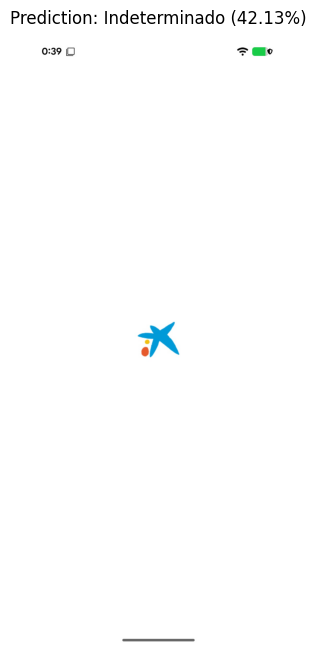

In [48]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert('RGB')

plt.figure(figsize=(5, 8))
plt.imshow(image)
plt.title(f"Prediction: {label} ({conf:.2%})")
plt.axis('off')
plt.show()
